# Tutorial 201: Conditional Flow Matching on Synthetic Data

In Tutorial 100 & 110 the model learned one fixed map — Gaussian Noise -> two-moons & PBMC data

We split the top moon into two sub-populations:
- **Condition A** (`label='0'`): left half of the top moon (x < 0)
- **Condition B** (`label='2'`): right half of the top moon (x ≥ 0)

The source is the bottom moon (`label='1'`). At inference the model pushes the source cells
toward the correct target half depending on the condition.

In [1]:
%load_ext autoreload
%autoreload 2

## Contents

* **Section 1**: Data
* **Section 2**: SCFlow Register Setup
* **Section 3**: Model Setup
* **Section 4**: Training
* **Section 5**: Saving & Loading Model
* **Section 6**: Testing
* **Section 7**: ODE Trajectories

In [2]:
import anndata as ad
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

from sc_flow import SCFlow
from sc_flow.dataset.toy_data import get_toy_dataset


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

## Section 1: Data Creation

We generate the two-moons dataset and split the top moon into two
sub-populations by x-coordinate:

- `x < 0` → keeps label `'0'` (left half, Condition A)
- `x ≥ 0` → relabelled `'2'` (right half, Condition B)

and the bottom moon is labelled `'1'`

We then compute representations for these three labels using OHE and store the lookup table in `adata.uns['label_reps']`.

In [3]:
dataset = get_toy_dataset("moons", n_samples=10_000, noise=0.1, random_state=SEED)
adata = dataset.adata
print(adata)

AnnData object with n_obs × n_vars = 10000 × 2
    uns: 'dataset_info'
    obsm: 'Y'


In [4]:
# Use .ravel() to flatten else we get a 2D boolean array due to broadcasting
right_mask = (adata.obsm["Y"].ravel() == "0") & (np.array(adata.X)[:, 0] >= 0)
adata.obsm["Y"][right_mask] = "2"
adata.obs["labels"] = adata.obsm[
    "Y"
]  # necessary for whe register the adata with SCFlow below, which expects condition labels in obs

unique, counts = np.unique(adata.obsm["Y"], return_counts=True)

print("label counts")
dict(zip(unique, counts, strict=True))

label counts


{np.str_('0'): np.int64(2496),
 np.str_('1'): np.int64(5000),
 np.str_('2'): np.int64(2504)}

In [5]:
# One-hot encode all labels and store in uns
encoder = OneHotEncoder(sparse_output=False)
unique_labels = np.unique(adata.obsm["Y"]).reshape(-1, 1)
one_hots = encoder.fit_transform(unique_labels)
adata.uns["label_reps"] = {str(lbl[0]): vec for lbl, vec in zip(unique_labels, one_hots, strict=False)}

print("\nCondition embeddings (one-hot):")
for k, v in adata.uns["label_reps"].items():
    print(f"  label '{k}': {v}")


Condition embeddings (one-hot):
  label '0': [1. 0. 0.]
  label '1': [0. 1. 0.]
  label '2': [0. 0. 1.]


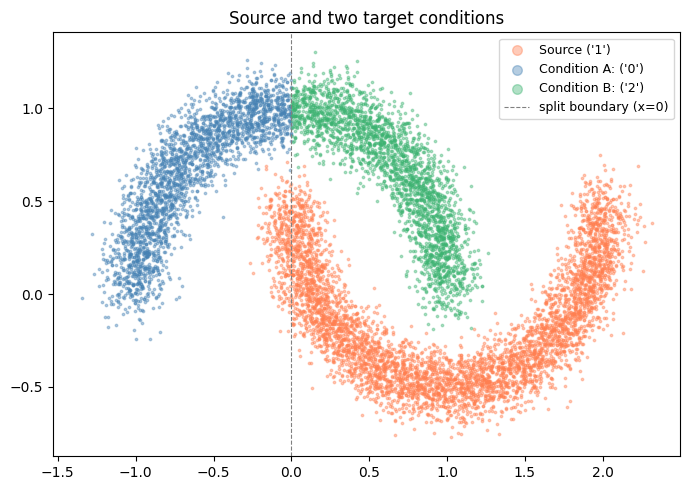

In [6]:
X = np.array(adata.X)
labels = adata.obsm["Y"].ravel()

colors = {"1": "coral", "0": "steelblue", "2": "mediumseagreen"}
names = {
    "1": "Source ('1')",
    "0": "Condition A: ('0')",
    "2": "Condition B: ('2')",
}

fig, ax = plt.subplots(figsize=(7, 5))
for lbl in ["1", "0", "2"]:
    mask = labels == lbl
    ax.scatter(X[mask, 0], X[mask, 1], s=3, alpha=0.4, color=colors[lbl], label=names[lbl])
ax.axvline(0, color="gray", lw=0.8, linestyle="--", label="split boundary (x=0)")
ax.set_title("Source and two target conditions")
ax.legend(markerscale=4, fontsize=9)
plt.tight_layout()
plt.show()

## Section 2: SCFlow Register Setup

This time we also have different conditions for our dataset which we will have to configure when registering the adata.

- `conditions={'moon': ['label']}` — Searches for the conditions data in `.obs['label]`
- `conditions_reps={'moon': 'label_reps'}` — Looks up embeddings for the conditions in `.uns['label_reps']`
- `control_values_dict={'moon': '1'}` — Setting up cells labelled `'1'` as the source population

In [7]:
adata

AnnData object with n_obs × n_vars = 10000 × 2
    obs: 'labels'
    uns: 'dataset_info', 'label_reps'
    obsm: 'Y'

In [8]:
SCFlow.register_adata(
    adata,
    sample_rep=None,
    conditions={"moon": ["labels"]},
    conditions_reps={"moon": "label_reps"},
    control_values_dict={"moon": "1"},
)

In [9]:
print("state_dim:                   ", SCFlow._dims_registry.state_dim)
print("feature_names:               ", SCFlow._dims_registry.feature_names)
print("condition_reps_dims:         ", SCFlow._dims_registry.condition_reps_dims)
print("condition_continuous_dims:   ", SCFlow._dims_registry.condition_continuous_dims)
print("source_lin_dim:              ", SCFlow._dims_registry.source_lin_dim)
print("source_quad_dim:             ", SCFlow._dims_registry.source_quad_dim)
print("target_lin_dim:              ", SCFlow._dims_registry.target_lin_dim)
print("target_quad_dim:             ", SCFlow._dims_registry.target_quad_dim)

state_dim:                    2
feature_names:                Index(['0', '1'], dtype='object')
condition_reps_dims:          {'moon': 3}
condition_continuous_dims:    {}
source_lin_dim:               2
source_quad_dim:              None
target_lin_dim:               2
target_quad_dim:              None


## Section 3: Model Setup

Now we create an SCFlow model instance. In addition to the parameters used in the last notebooks, we introduce a few additional parameters here.

* `condition_encoder_input_layers` — wires the condition encoder into the velocity field. It is a dict keyed by the name used in `register_adata` (here `"moon"`). Each value is a config dict for that covariate's input projection; `output_dim` sets the size of the per-covariate embedding before it is pooled and passed to the decoder. 
> **Note**: registering conditions via `register_adata` does NOT auto-wire this — if you omit `condition_encoder_input_layers`, the condition is silently dropped and the model trains as unconditional.
* `vf_decoder_mlp_kwargs` — configures the MLP decoder (the network that takes state + time + condition and outputs a velocity vector). Pass `hidden_dims` as a list of ints, each entry adds one hidden layer of that width. Without this argument the decoder defaults to a single linear layer
* `backend` tells SCFlow whether to use `torch` or `jax`. Defaults to `torch` if not provided.

In [10]:
model = SCFlow(
    method_id="cfm",
    backend="torch",
    condition_encoder_input_layers={
        "moon": {"output_dim": 64},
    },
    # time_features_id = 'torch-cfm',
    # probability_path=LinearGaussianProbabilityPath(sigma=0.01),
    vf_decoder_mlp_kwargs={
        "hidden_dims": [
            32,
            32,
        ]
    },
    # conditioning_id="resnet1d",
)

> **Ask**:
>
> 1. **Default decoder depth**: `MLP` defaults to `hidden_dims=None` → `hidden_dims=()` → single linear layer, no non-linearity. Without explicitly passing `vf_decoder_mlp_kwargs={"hidden_dims": [...]}`, the decoder is just a linear projection and the model can only learn affine transport maps. Should the default be something like `(64, 64)`?
>
> 2. **Condition encoder not auto-wired**: `register_adata(conditions={"moon": [...]}, ...)` populates `_dims_registry` with condition dimensions, but `MLPVelocity` does NOT automatically build a condition encoder from this. You must also explicitly pass `condition_encoder_input_layers={"moon": {...}}` to `SCFlow(...)`. If you forget, `MLPVelocity.is_conditional = False` and the condition is silently dropped — the model trains as unconditional with no error or warning. Should there be a warning when registered conditions are not used by the VF?

In [11]:
print(f"Backend:         {model.backend}")
print(f"DataManager:     {model.dm}")
print(f"Method:          {model.method}")
print(f"Paired Settings: {model.is_paired_setting}")

Backend:         torch
DataManager:     <sc_flow.data._manager.DataManager object at 0x000001D2C4FD57F0>
Method:          <sc_flow.backends.torch.methods.library._cfm.CFM object at 0x000001D2CAF8C2F0>
Paired Settings: True


Due to the same problem we had in `100` & `110`, we use `.sort_adata` for sorting.

In [12]:
adata = model.dm.sort_adata(adata)

tree = model.dm.compile_adata(adata).flatten()

c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 2/2 [00:00<00:00, 4058.35it/s]


## Section 4: Training

Training the model via the SCFlow instance is straightforward as shown here. It creates a `trainer` which holds all the logs for training and validation, accessible as a `pd.DataFrame`.

In [13]:
BATCH_SIZE = 512
model.train(
    adata,
    n_train_steps=10_000,
    train_batch_size=BATCH_SIZE,
    optim_kwargs={"lr": 1e-3},
)

100%|██████████| 2/2 [00:00<00:00, 4324.02it/s]
| loss:0.1648 | step:10000: 100%|██████████| 10000/10000 [01:34<00:00, 105.79it/s]


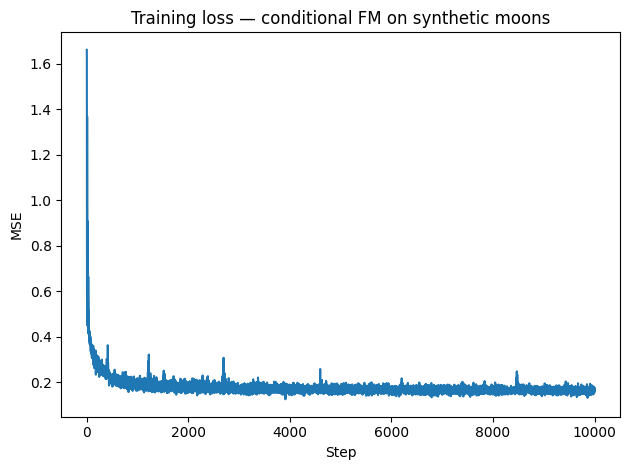

In [14]:
logs_df = model.trainer.get_train_logs_df()
plt.plot(logs_df.index, logs_df["loss"])
plt.title("Training loss — conditional FM on synthetic moons")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.tight_layout()
plt.show()

In [15]:
model.save(filepath="cfm_moons_conditional_model.pt", allow_overwrite=True)

## Section 6: Testing

We pass the full adata to `model.predict` — the DataManager automatically pairs source cells
(label `'1'`) with each target condition and predicts one transport map per condition.
The returned AnnData has an `obs['label']` column identifying which condition each prediction
belongs to, so we can split them for plotting.

In [16]:
adata_pred = model.predict(adata)
print(adata_pred)
print(adata_pred.obs["labels"].value_counts())

Predicting: 100%|██████████| 2/2 [00:01<00:00,  1.58it/s]

AnnData object with n_obs × n_vars = 10000 × 2
    obs: 'labels'
labels
0    5000
2    5000
1       0
Name: count, dtype: int64



C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\anndata\_core\anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


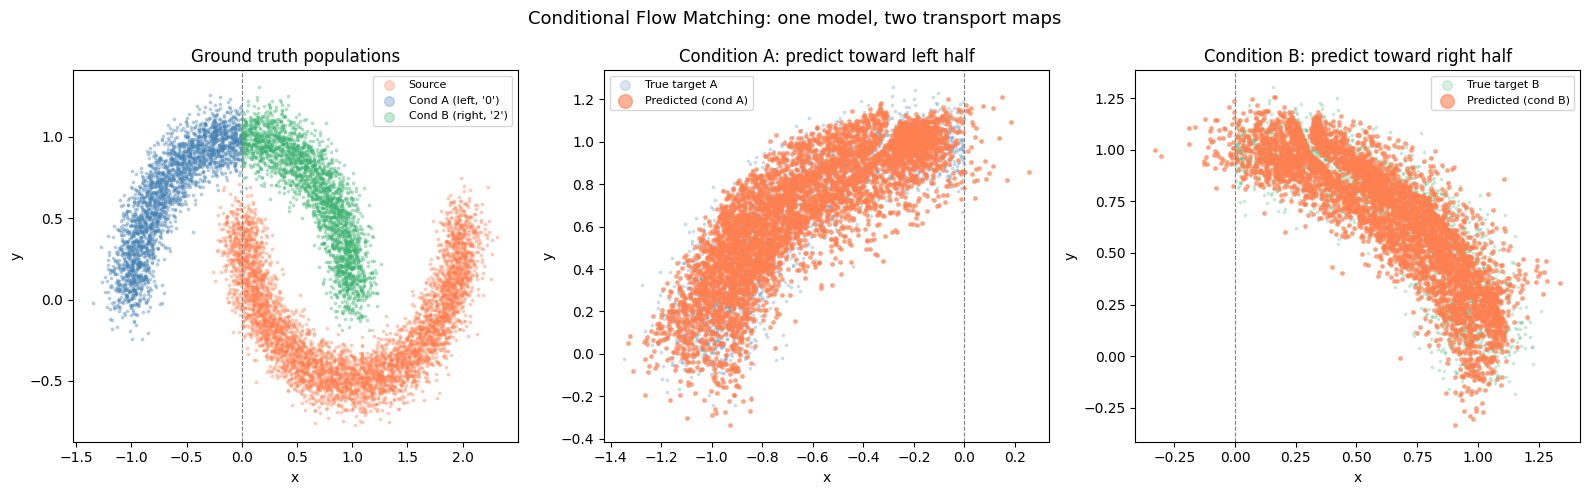

In [17]:
src_np = X[labels == "1"]
tgt_a = X[labels == "0"]
tgt_b = X[labels == "2"]
pred_a = np.array(adata_pred[adata_pred.obs["labels"] == "0"].X)
pred_b = np.array(adata_pred[adata_pred.obs["labels"] == "2"].X)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ground truth
axes[0].scatter(src_np[:, 0], src_np[:, 1], s=3, alpha=0.3, color="coral", label="Source")
axes[0].scatter(tgt_a[:, 0], tgt_a[:, 1], s=3, alpha=0.3, color="steelblue", label="Cond A (left, '0')")
axes[0].scatter(tgt_b[:, 0], tgt_b[:, 1], s=3, alpha=0.3, color="mediumseagreen", label="Cond B (right, '2')")
axes[0].axvline(0, color="gray", lw=0.8, linestyle="--")
axes[0].set_title("Ground truth populations")
axes[0].legend(markerscale=4, fontsize=8)

# Condition A predictions
axes[1].scatter(tgt_a[:, 0], tgt_a[:, 1], s=3, alpha=0.2, color="steelblue", label="True target A")
axes[1].scatter(pred_a[:, 0], pred_a[:, 1], s=6, alpha=0.6, color="coral", label="Predicted (cond A)")
axes[1].axvline(0, color="gray", lw=0.8, linestyle="--")
axes[1].set_title("Condition A: predict toward left half")
axes[1].legend(markerscale=4, fontsize=8)

# Condition B predictions
axes[2].scatter(tgt_b[:, 0], tgt_b[:, 1], s=3, alpha=0.2, color="mediumseagreen", label="True target B")
axes[2].scatter(pred_b[:, 0], pred_b[:, 1], s=6, alpha=0.6, color="coral", label="Predicted (cond B)")
axes[2].axvline(0, color="gray", lw=0.8, linestyle="--")
axes[2].set_title("Condition B: predict toward right half")
axes[2].legend(markerscale=4, fontsize=8)

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.suptitle("Conditional Flow Matching: one model, two transport maps", fontsize=13)
plt.tight_layout()
plt.show()

## Section 7: ODE Trajectories

Under condition A the paths curve left; under condition B they curve right —
even though the starting point and the network weights are identical.
The only difference is the one-hot encoded condition.

In [18]:
N_TRAJ = 30

# Build a small adata with source cells + condition A targets
src_sub = src_np[:N_TRAJ]
tgt_a_sub = tgt_a[:N_TRAJ]

adata_sub_a = ad.AnnData(
    X=np.vstack([src_sub, tgt_a_sub]),
    obs=pd.DataFrame({"labels": ["1"] * N_TRAJ + ["0"] * N_TRAJ}),
)
adata_sub_b = ad.AnnData(
    X=np.vstack([src_sub, tgt_b[:N_TRAJ]]),
    obs=pd.DataFrame({"labels": ["1"] * N_TRAJ + ["2"] * N_TRAJ}),
)

# DataManager needs the label_reps lookup table in uns
adata_sub_a.uns["label_reps"] = adata.uns["label_reps"]
adata_sub_b.uns["label_reps"] = adata.uns["label_reps"]
adata_sub_a = model.dm.sort_adata(adata_sub_a)
adata_sub_b = model.dm.sort_adata(adata_sub_b)

adata_traj_a = model.predict(adata_sub_a, return_trajectory=True, num_steps=20)
adata_traj_b = model.predict(adata_sub_b, return_trajectory=True, num_steps=20)

traj_a = adata_traj_a.obsm["trajectory"]  # shape: (n_cells, n_steps, state_dim)
traj_b = adata_traj_b.obsm["trajectory"]
print(f"trajectory A shape: {traj_a.shape}")
print(f"trajectory B shape: {traj_b.shape}")

C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Predicting: 100%|██████████| 1/1 [00:00<00:00, 49.98it/s]
C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Predicting: 100%|██████████| 1/1 [00:00<00:00, 56.96it/s]

trajectory A shape: (30, 20, 2)
trajectory B shape: (30, 20, 2)



C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


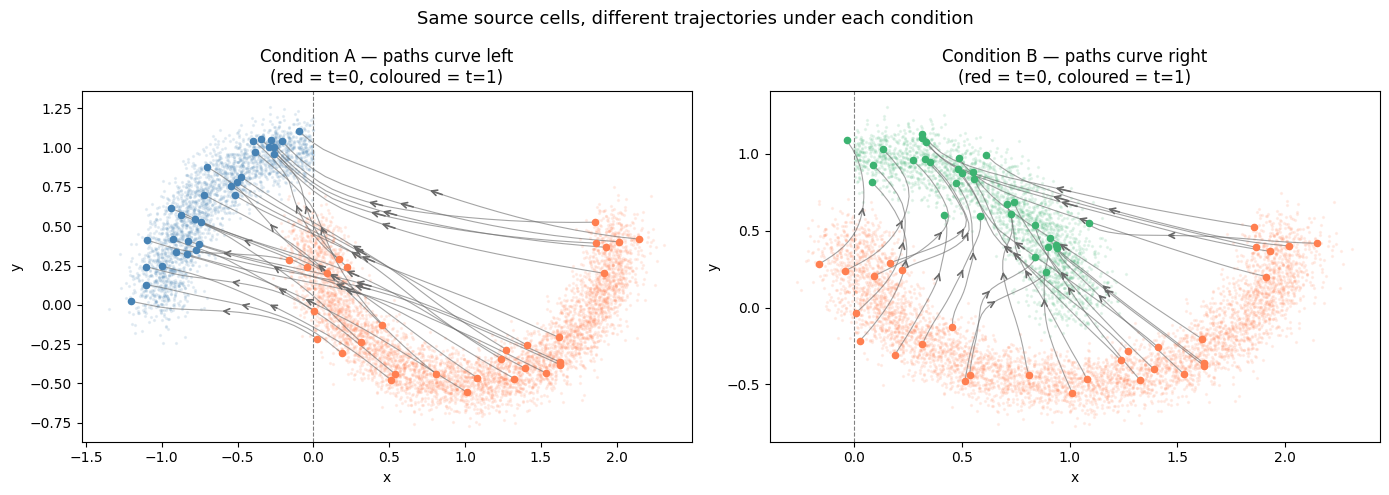

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, traj, tgt_np, title, tgt_color in [
    (axes[0], traj_a, tgt_a, "Condition A — paths curve left", "steelblue"),
    (axes[1], traj_b, tgt_b, "Condition B — paths curve right", "mediumseagreen"),
]:
    ax.scatter(src_np[:, 0], src_np[:, 1], s=2, alpha=0.1, color="coral")
    ax.scatter(tgt_np[:, 0], tgt_np[:, 1], s=2, alpha=0.1, color=tgt_color)
    ax.axvline(0, color="gray", lw=0.8, linestyle="--")

    mid = traj.shape[1] // 2
    for i in range(N_TRAJ):
        ax.plot(traj[i, :, 0], traj[i, :, 1], lw=0.8, alpha=0.6, color="dimgray")
        ax.annotate(
            "",
            xy=(traj[i, mid + 1, 0], traj[i, mid + 1, 1]),
            xytext=(traj[i, mid, 0], traj[i, mid, 1]),
            arrowprops={"arrowstyle": "->", "color": "dimgray", "lw": 1.2},
        )
        ax.scatter(traj[i, 0, 0], traj[i, 0, 1], s=20, color="coral", zorder=5)
        ax.scatter(traj[i, -1, 0], traj[i, -1, 1], s=20, color=tgt_color, zorder=5)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"{title}\n(red = t=0, coloured = t=1)")

plt.suptitle("Same source cells, different trajectories under each condition", fontsize=13)
plt.tight_layout()
plt.show()

### What's next?

| Tutorial | What it introduces |
|---|---|
| [`211_conditional_fm_pbmc.ipynb`](211_conditional_fm_pbmc.ipynb) | Same concept on real PBMC data with 90 cytokine conditions and ESM2 embeddings |